In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
sns.set()


In [15]:
print(os.listdir())

['.config', 'StudentsPerformance.csv', 'sample_data']


In [16]:
df=pd.read_csv('./StudentsPerformance.csv')

In [17]:
df.head()
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [18]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [19]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [20]:
df.sample(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
303,male,group B,associate's degree,standard,none,80,76,64
153,male,group D,bachelor's degree,standard,none,54,49,47
402,female,group A,some college,free/reduced,none,49,65,55
408,female,group D,high school,free/reduced,completed,52,57,56
246,male,group E,associate's degree,standard,none,89,76,74


pandas.core.frame.DataFrame

<Figure size 1000x500 with 0 Axes>

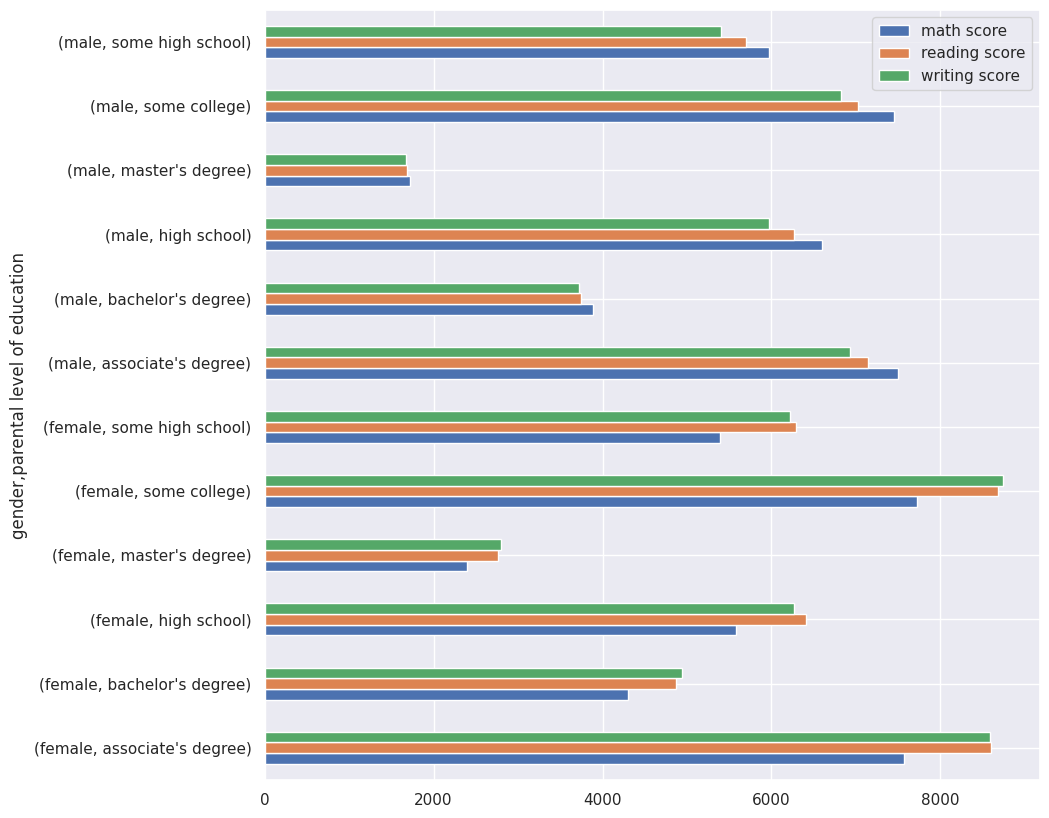

In [21]:
plt.figure(figsize=(10,5))
parental_level=df.groupby(['gender','parental level of education'])[['math score','reading score','writing score']].sum()
parental_level.columns
parental_level.plot.barh(figsize=(10,10))
type(parental_level)
# sns.barplot(parental_level,x=parental_level.columns.any(),y=parental_level.values)

In [22]:
parental_level

math score  reading score  writing score
gender parental level of education                                          
female associate's degree                 7569           8598           8584
       bachelor's degree                  4306           4869           4938
       high school                        5579           6411           6269
       master's degree                    2394           2765           2795
       some college                       7718           8679           8738
       some high school                   5396           6289           6214
male   associate's degree                 7501           7148           6933
       bachelor's degree                  3882           3745           3721
       high school                        6600           6271           5971
       master's degree                    1721           1682           1670
       some college                       7453           7019           6820
       some high school                   5970           5693           5401

In [23]:
male=df.query("gender=='male'")
female=df.query("gender=='female'")

In [24]:
df.groupby(['gender','parental level of education'])[['math score','reading score','writing score']].mean()

math score  reading score  writing score
gender parental level of education                                          
female associate's degree            65.250000      74.120690      74.000000
       bachelor's degree             68.349206      77.285714      78.380952
       high school                   59.351064      68.202128      66.691489
       master's degree               66.500000      76.805556      77.638889
       some college                  65.406780      73.550847      74.050847
       some high school              59.296703      69.109890      68.285714
male   associate's degree            70.764151      67.433962      65.405660
       bachelor's degree             70.581818      68.090909      67.654545
       high school                   64.705882      61.480392      58.539216
       master's degree               74.826087      73.130435      72.608696
       some college                  69.009259      64.990741      63.148148
       some high school              67.840909      64.693182      61.375000

<Axes: >

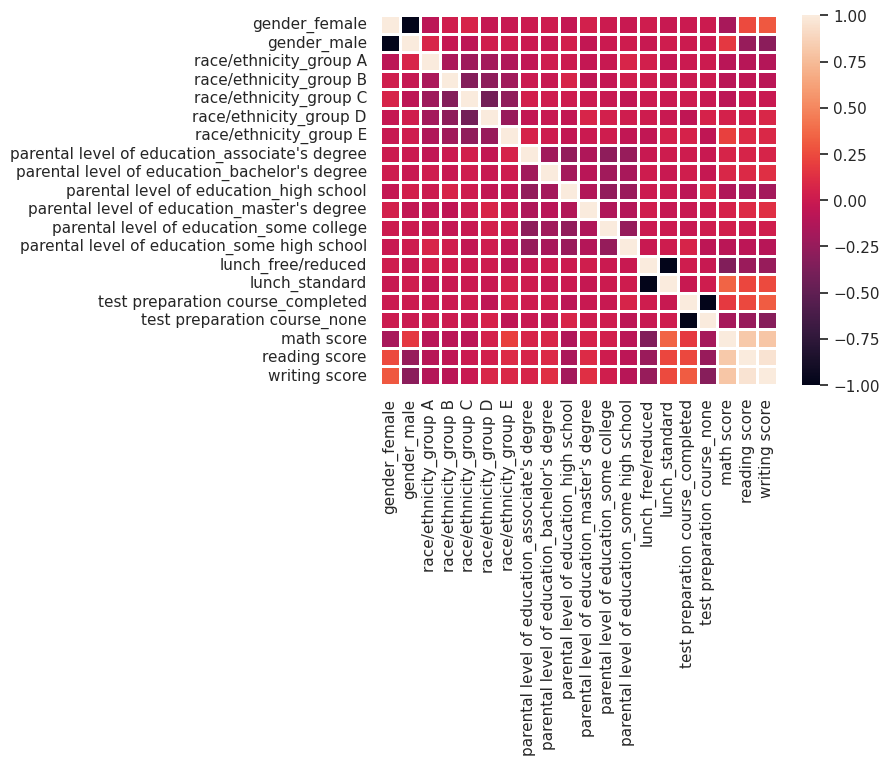

In [25]:
object_data=df.select_dtypes(include=['object']).columns[0:]
# object_data
numeric_data=df.select_dtypes(include=['number']).columns[0:]
dummies=pd.get_dummies(df[object_data]).join(df[numeric_data])
corrlation=dummies.corr()
sns.heatmap(corrlation,linewidth=0.8,)

In [26]:
# item=corrlation['math score'].items()
# for i , k in item:
#     # print(k)
#     if k >= 0.5 and i != 'math score':
#         print(k,i)
# df.apply(lambda x:type(x) )
# high_score=df[(df['math score']>= 80)& (df['reading score']>= 80)& (df['writing score']>=80)]
# high_score
df['high_score']=df['math score']+df['reading score']+df['writing score']
# df['high_score']
# df[df['high_score']>=240]

quantile=df[['math score','reading score','writing score']]
df['score']=pd.cut(df['high_score'],bins=[27,100,150,200,240,300],
       labels=['Weak','Acceptable','Good','Very Good','Excellent'])

# df['high_score'].min()
df.drop(columns=['high_score'],inplace=True)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,score
0,female,group B,bachelor's degree,standard,none,72,72,74,Very Good
1,female,group C,some college,standard,completed,69,90,88,Excellent
2,female,group B,master's degree,standard,none,90,95,93,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,Acceptable
4,male,group C,some college,standard,none,76,78,75,Very Good
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,Excellent
996,male,group C,high school,free/reduced,none,62,55,55,Good
997,female,group C,high school,free/reduced,completed,59,71,65,Good
998,female,group D,some college,standard,completed,68,78,77,Very Good


In [27]:
df.groupby(['gender','parental level of education'])[['math score','reading score','writing score']].std()

math score  reading score  writing score
gender parental level of education                                          
female associate's degree            14.879151      13.200893      13.307076
       bachelor's degree             15.635112      14.251688      13.750576
       high school                   15.123653      14.082384      14.378917
       master's degree               15.579290      14.830123      14.558557
       some college                  13.713950      12.392166      13.343488
       some high school              16.957132      16.606191      16.965511
male   associate's degree            14.905130      13.798564      14.077187
       bachelor's degree             14.158744      12.766090      13.796428
       high school                   13.551945      13.457473      12.669189
       master's degree               13.230997      11.906088      11.987642
       some college                  14.774628      14.456183      14.716521
       some high school              13.567106      13.961654      13.576782

In [28]:
df.replace({'none':np.nan},inplace=True)

# Why didn't I fill in the missing values? Because people don't want to choose completed
# so they don't take test preparation course

In [29]:
df['test preparation course'].isna().sum()

np.int64(642)

In [30]:
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,642
math score,0
reading score,0
writing score,0
score,1


In [31]:
# mode=df['test preparation course'].mode()
# df['test preparation course']=df['test preparation course'].fillna(mode[0])
# # mode[0]
# # df.head()
# df['test preparation course'].unique()

In [32]:
df.groupby('score')[['math score','reading score','writing score']].sum()

<ipython-input-32-5de6adda8ad8>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('score')[['math score','reading score','writing score']].sum()


,math score,reading score,writing score
score,,,
Weak,359,429,389
Acceptable,4162,4373,4160
Good,19839,20763,20351
Very Good,25174,26419,26111
Excellent,16555,17168,17033


In [33]:
X=df[['math score','reading score','writing score']]
y=df['score']

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.35)

In [36]:
x_train

,math score,reading score,writing score
365,49,58,60
309,49,57,52
651,68,80,76
196,59,69,65
676,73,78,76
...,...,...,...
113,51,58,54
34,97,87,82
231,46,43,42
126,72,68,67


In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
encoding=['Weak','Acceptable','Good','Very Good','Excellent']
encoder=LabelEncoder()


[4, 0, 2, 3, 1]

In [39]:
df['encode_score']=df['score']
df['encode_score']=encoder.fit_transform(df['score'])

In [40]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,score,encode_score
0,female,group B,bachelor's degree,standard,NaN,72,72,74,Very Good,3
1,female,group C,some college,standard,completed,69,90,88,Excellent,1
2,female,group B,master's degree,standard,NaN,90,95,93,Excellent,1
3,male,group A,associate's degree,free/reduced,NaN,47,57,44,Acceptable,0
4,male,group C,some college,standard,NaN,76,78,75,Very Good,3
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,Excellent,1
996,male,group C,high school,free/reduced,NaN,62,55,55,Good,2
997,female,group C,high school,free/reduced,completed,59,71,65,Good,2
998,female,group D,some college,standard,completed,68,78,77,Very Good,3
